In [ ]:
import scanpy as sc
import pandas as pd
import numpy as np
import squidpy as sq
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


c:\Users\sevco\Documents\diplomka\DiplomaThesis\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\sevco\Documents\diplomka\DiplomaThesis\venv\Lib\site-packages\docrep\decorators.py:43: SyntaxWarning: 'n_jobs' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
c:\Users\sevco\Documents\diplomka\DiplomaThesis\venv\Lib\site-packages\docrep\decorators.py:43: SyntaxWarning: 'show_progress_bar' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


In [2]:
import utils.paths as d
import utils.utils as u
import utils.functions as f

c:\Users\sevco\Documents\diplomka\DiplomaThesis\venv\Lib\site-packages\anndata\_core\anndata.py:1882: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [ ]:
adata = sc.read_h5ad(d.preprocessed_dir / "adata_annotated_refined_10.h5ad")
adatas = {
    "wt_1": adata[adata.obs["sample"] == "wt_1"],
    "wt_2": adata[adata.obs["sample"] == "wt_2"],
    "wt_3": adata[adata.obs["sample"] == "wt_3"],
    "wt_4": adata[adata.obs["sample"] == "wt_4"],
    "mut_1": adata[adata.obs["sample"] == "mut_1"],
    "mut_2": adata[adata.obs["sample"] == "mut_2"],
    "mut_3": adata[adata.obs["sample"] == "mut_3"],
    "mut_4": adata[adata.obs["sample"] == "mut_4"],
}

# Vsetky samples + anotace

In [ ]:
sc.pp.neighbors(adata, n_neighbors=15, use_rep="X_pca", random_state=42)  # recompute
sc.tl.diffmap(adata)

In [8]:
sc.pp.neighbors(adata, n_neighbors=15, use_rep="X_diffmap", key_added="neighbors_diffmap", random_state=42)
sc.tl.leiden(adata, resolution=1.0, key_added="leiden_diffmap", random_state=42)

C:\Users\sevco\AppData\Local\Temp\ipykernel_28476\3527484651.py:2: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=1.0, key_added="leiden_diffmap", random_state=42)


In [9]:
sc.tl.paga(adata, groups="annotation", neighbors_key="neighbors_diffmap")

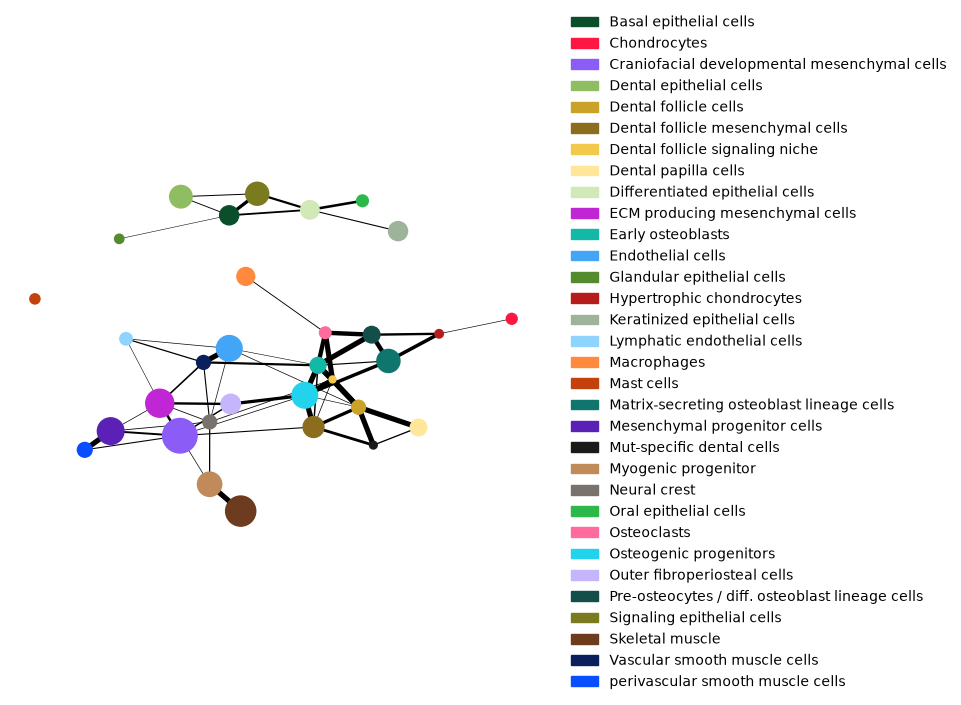

In [ ]:
sc.tl.paga(adata, groups="annotation", neighbors_key="neighbors_diffmap")
cats = adata.obs[adata.uns["paga"]["groups"]].cat.categories
n_groups = len(adata.obs[adata.uns["paga"]["groups"]].cat.categories)
adata.uns["annotation_colors"] = [u.L2_COLORS.get(c, "#CCCCCC") for c in cats]

ax = sc.pl.paga(adata, color="annotation", threshold=0.1, frameon=False,
                edge_width_scale=0.5, node_size_scale=1.2, node_size_power=0.8
                labels=[""] * n_groups, show=False)

ax.legend(handles=[Patch(color=u.L2_COLORS.get(c, "#CCCCCC"), label=c) for c in cats],
          loc="center left", bbox_to_anchor=(1, 0.5), frameon=False)
plt.show()

# Subcluster - vyber anotovanych clusterov

TODO:
Vyhadzujeme
- Mast cells
- Perivascular smooth muscle cells
- Vascular smooth muscle cells
- Endothelial cells
- Glandular epithelial cells
- Myogenic progenitor
- Mesenchymal progenitor cells
- Oral epithelial cells

In [12]:
exclude = [
    "Mast cells",
    "Skeletal muscle",
    "perivascular smooth muscle cells",
    "Vascular smooth muscle cells",
    "Endothelial cells",
    "Glandular epithelial cells",
    "Myogenic progenitor",
    "Mesenchymal progenitor cells",
    "Oral epithelial cells",
    "Keratinized epithelial cells",
    "Lymphatic endothelial cells",
    "Signaling epithelial cells",
    "Craniofacial developmental mesenchymal cells",
    "ECM producing mesenchymal cells",

]

# catch typos: names in the list that don't exist in the data
missing = set(exclude) - set(adata.obs["annotation"].cat.categories)
if missing:
    print("Not found in annotation:", missing)

adata_sub = adata[~adata.obs["annotation"].isin(exclude)].copy()

# drop the now-empty categories and realign colors
adata_sub.obs["annotation"] = adata_sub.obs["annotation"].cat.remove_unused_categories()
adata_sub.uns["annotation_colors"] = [
    u.L2_COLORS.get(c, "#CCCCCC") for c in adata_sub.obs["annotation"].cat.categories
]

print(adata.n_obs, "->", adata_sub.n_obs)
print(adata_sub.obs["annotation"].value_counts())

200725 -> 80722
annotation
Osteogenic progenitors                             11960
Matrix-secreting osteoblast lineage cells           9265
Dental epithelial cells                             8663
Dental follicle mesenchymal cells                   7197
Outer fibroperiosteal cells                         6070
Basal epithelial cells                              5730
Differentiated epithelial cells                     5324
Macrophages                                         4840
Pre-osteocytes / diff. osteoblast lineage cells     4012
Dental papilla cells                                4005
Early osteoblasts                                   3623
Dental follicle cells                               2617
Neural crest                                        2528
Osteoclasts                                         1649
Chondrocytes                                        1415
Hypertrophic chondrocytes                            762
Mut-specific dental cells                            601
Dent

c:\Users\sevco\Documents\diplomka\DiplomaThesis\venv\Lib\site-packages\anndata\_core\anndata.py:1882: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Tym ze sme si vybrali len dane clustery, tak si musime vypocitat PCA, neighbors a UMAP nanovo, pretoze sa zmeni globalna struktura dat.

In [68]:
# graph for the subset: PCA -> kNN -> diffusion map -> kNN on diffusion components
sc.pp.pca(adata_sub, n_comps=50, random_state=42)
sc.pp.neighbors(adata_sub, n_neighbors=25, use_rep="X_pca", random_state=42)
sc.tl.diffmap(adata_sub, n_comps=15)

# DC0 is the trivial eigenvector -> leave it out of the graph, but keep X_diffmap intact for sc.tl.dpt
adata_sub.obsm["X_diffmap_nt"] = adata_sub.obsm["X_diffmap"][:, 1:]
sc.pp.neighbors(adata_sub, n_neighbors=25, use_rep="X_diffmap_nt",
                key_added="neighbors_diffmap", random_state=42)

## Taktika: 
- ak nechame len anotovane clustre, tak PAGA nezachytava vyssiu strukturu dat inak ako UMAP.
- aby sme vyuzili PAGA lepsie, vytvorime si subclustre v clustroch ktore nas zaujimaju. Tymto sa nam moze podarit zachytit aj vyssiu strukturu dat, pretoze subclustre budu mat vacsiu granularitu a PAGA bude mat viac hran.

Parametre:
- `SUB_RES` - leiden resolution inside each annotation, cim vyssia hodnota, tym viac subclusterov
- `MIN_CELLS` - ak je pocet celkovych buniek v anotovanych clusteroch mensia ako tato hodnota, tak sa subclusterovanie neaplikuje
- `MIN_SUB` - ak je pocet buniek v subclustri mensi ako tato hodnota, tak sa subcluster priradi k najblizsiemu subclustru

In [69]:
# subcluster every annotation separately (leiden restricted to the cells of one annotation)
SUB_RES = 0.05      # leiden resolution inside each annotation
MIN_CELLS = 400    # smaller annotations stay as one subcluster
MIN_SUB = 100       # smaller subclusters (cells isolated inside the restricted graph) get merged back

adata_sub.obs["annotation_sub"] = adata_sub.obs["annotation"].astype(str) + ",0"
for ann in adata_sub.obs["annotation"].cat.categories:
    mask = (adata_sub.obs["annotation"] == ann).values
    if mask.sum() < MIN_CELLS:
        continue
    sc.tl.leiden(adata_sub, resolution=SUB_RES, restrict_to=("annotation", [ann]),
                 neighbors_key="neighbors_diffmap", key_added="_tmp", random_state=42)
    adata_sub.obs.loc[mask, "annotation_sub"] = adata_sub.obs.loc[mask, "_tmp"].astype(str)
adata_sub.obs.drop(columns="_tmp", inplace=True)
adata_sub.uns.pop("_tmp", None)

# merge tiny subclusters: each cell goes to the most connected large subcluster of the same annotation
conn = adata_sub.obsp["neighbors_diffmap_connectivities"].tocsr()
labels = adata_sub.obs["annotation_sub"].to_numpy(dtype=object)
ann_arr = adata_sub.obs["annotation"].to_numpy(dtype=object)
sizes = pd.Series(labels).value_counts()
is_tiny = pd.Series(labels).isin(sizes.index[sizes < MIN_SUB]).to_numpy()
largest = pd.Series(labels[~is_tiny]).groupby(ann_arr[~is_tiny]).agg(lambda s: s.value_counts().index[0])
new = labels.copy()
for i in np.flatnonzero(is_tiny):
    nb, w = conn.indices[conn.indptr[i]:conn.indptr[i + 1]], conn.data[conn.indptr[i]:conn.indptr[i + 1]]
    ok = ~is_tiny[nb] & (ann_arr[nb] == ann_arr[i])
    new[i] = pd.Series(w[ok]).groupby(labels[nb][ok]).sum().idxmax() if ok.any() else largest[ann_arr[i]]
adata_sub.obs["annotation_sub"] = new
print(f"merged {is_tiny.sum()} cells from {(sizes < MIN_SUB).sum()} tiny subclusters")

# short numeric ids ("0", "1", ...) ordered by parent annotation -> used as PAGA nodes and ROOT
lookup = (adata_sub.obs.groupby(["annotation", "annotation_sub"], observed=True)
          .size().rename("n_cells").reset_index())
lookup["_k"] = lookup["annotation_sub"].str.rsplit(",", n=1).str[-1].astype(int)
lookup = lookup.sort_values(["annotation", "_k"]).drop(columns="_k").reset_index(drop=True)
lookup["subcluster"] = lookup.index.astype(str)
adata_sub.obs["subcluster"] = pd.Categorical(
    adata_sub.obs["annotation_sub"].map(dict(zip(lookup["annotation_sub"], lookup["subcluster"]))),
    categories=lookup["subcluster"],
)
# colours: each annotation's base colour fading towards grey across its subclusters (subcluster 0 = base colour)
from matplotlib.colors import to_rgb, to_hex

def shades(base, n, grey="#bdbdbd", max_mix=0.75):
    b, g = np.array(to_rgb(base)), np.array(to_rgb(grey))
    return [to_hex((1 - t) * b + t * g) for t in np.linspace(0, max_mix if n > 1 else 0, n)]

sub_colors = {}
for ann, grp in lookup.groupby("annotation", observed=True, sort=False):
    sub_colors.update(zip(grp["subcluster"], shades(u.L2_COLORS.get(ann, "#CCCCCC"), len(grp))))
lookup["color"] = lookup["subcluster"].map(sub_colors)
adata_sub.uns["subcluster_colors"] = [sub_colors[s] for s in adata_sub.obs["subcluster"].cat.categories]
adata_sub.uns["annotation_colors"] = [u.L2_COLORS.get(c, "#CCCCCC") for c in adata_sub.obs["annotation"].cat.categories]

print(lookup[["subcluster", "annotation", "annotation_sub", "n_cells"]].to_string(index=False))

merged 800 cells from 324 tiny subclusters
subcluster                                      annotation                                    annotation_sub  n_cells
         0                          Basal epithelial cells                          Basal epithelial cells,0     3710
         1                          Basal epithelial cells                          Basal epithelial cells,1     2020
         2                                    Chondrocytes                                    Chondrocytes,0      332
         3                                    Chondrocytes                                    Chondrocytes,1      303
         4                                    Chondrocytes                                    Chondrocytes,2      291
         5                                    Chondrocytes                                    Chondrocytes,3      280
         6                                    Chondrocytes                                    Chondrocytes,4      209
         7   

Parameter:
- `THRESHOLD` - threshold for filtering edges in the PAGA graph, cim vyssia hodnota, tym menej hran v grafe

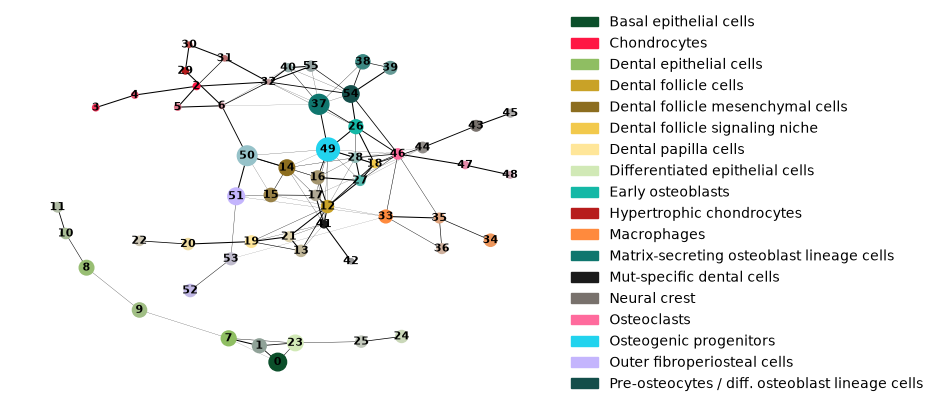

In [75]:
THRESHOLD = 0.1

sc.tl.paga(adata_sub, groups="subcluster", neighbors_key="neighbors_diffmap")
cats = adata_sub.obs["annotation"].cat.categories

# nodes = subclusters (labelled by id), colour = shade of the parent annotation colour
ax = sc.pl.paga(adata_sub, color="subcluster", threshold=THRESHOLD, frameon=False,
                edge_width_scale=0.1, node_size_scale=0.5, node_size_power=0.8,
                fontsize=8, show=False)

ax.legend(handles=[Patch(color=u.L2_COLORS.get(c, "#ACACAC"), label=c) for c in cats],
          loc="center left", bbox_to_anchor=(1, 0.5), frameon=False)
plt.show()

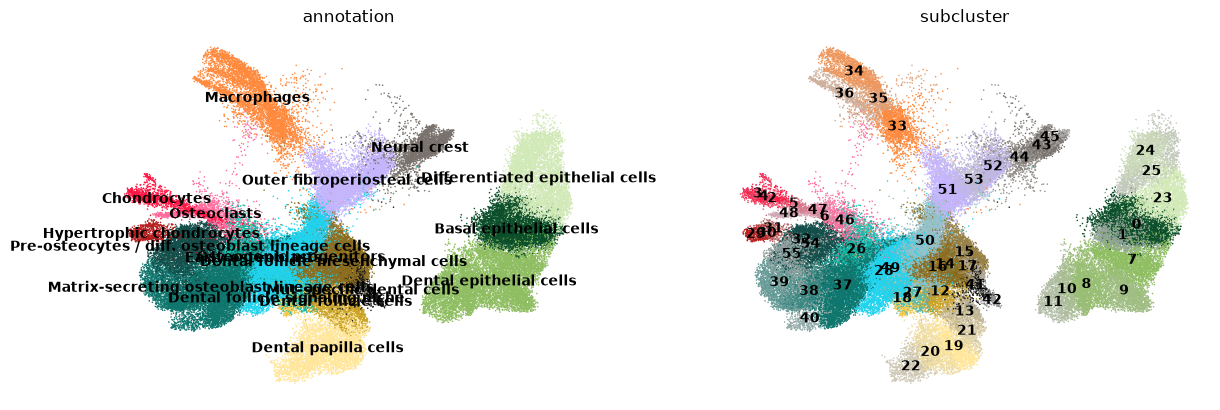

In [76]:
sc.pl.embedding(adata_sub, basis="X_umap", color=["annotation", "subcluster"], size=5, frameon=False, legend_loc="on data")

Parameter
- `ROOT` - DOLEZITE: root vyuzity na orientaciu PAGA grafu a vypocet pseudocasovej osi

In [77]:
ROOT = "49"   # subcluster id from the lookup table above

root_cells = np.flatnonzero(adata_sub.obs["subcluster"] == ROOT)
assert root_cells.size, f"subcluster {ROOT} not found"
print("root:", lookup.loc[lookup["subcluster"] == ROOT, "annotation_sub"].item(), f"({root_cells.size} cells)")

# root cell = tip of the root subcluster: extreme on DC1, on the side facing away from the rest of the data
dc1 = adata_sub.obsm["X_diffmap"][:, 1]
side = np.sign(dc1[root_cells].mean() - dc1.mean()) or 1
adata_sub.uns["iroot"] = root_cells[np.argmax(side * dc1[root_cells])]

sc.tl.dpt(adata_sub, n_dcs=10)
print("cells without finite pseudotime:", (~np.isfinite(adata_sub.obs["dpt_pseudotime"])).sum())

root: Osteogenic progenitors,0 (7088 cells)
cells without finite pseudotime: 0


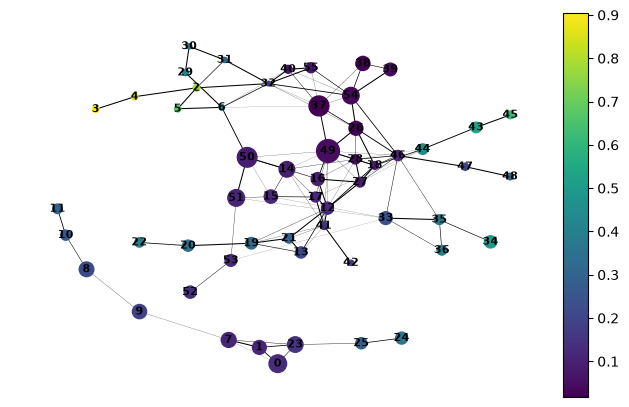

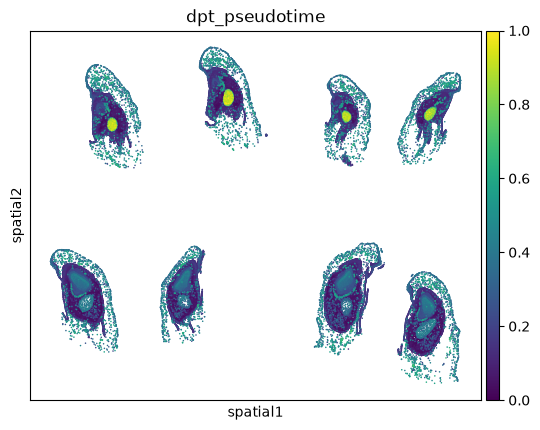

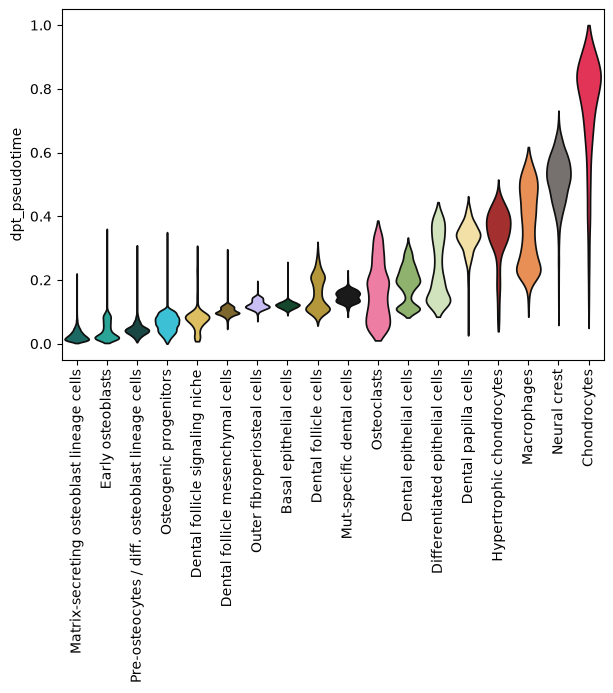

In [79]:
sc.pl.paga(adata_sub, color="dpt_pseudotime", threshold=THRESHOLD, frameon=False,
                edge_width_scale=0.1, node_size_scale=0.5, node_size_power=0.8,
                fontsize=8, cmap="viridis")
sc.pl.embedding(adata_sub, basis="spatial", color="dpt_pseudotime", size=5, cmap="viridis")

order = adata_sub.obs.groupby("annotation", observed=True)["dpt_pseudotime"].median().sort_values().index
sc.pl.violin(adata_sub, "dpt_pseudotime", groupby="annotation", order=list(order),
             rotation=90, stripplot=False)